<a href="https://colab.research.google.com/github/ArnoldG8/Training_Repository/blob/main/Simple_Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Linear Regression Steps

## 1. Import libraries and load excel sheet

In [28]:
# Import necessary libraries
import pandas as pd
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# Load your dataset using pandas
attendanceDataset = pd.read_excel("/content/Attendance_Prediction_Dataset_(Example).xlsx")

# View the first 5 values
attendanceDataset.head(5)

,Attendance,Grades
0,12,100
1,1,10
2,4,40
3,3,30
4,2,20


## 2. Prepare the data

### 2.1 Store the dependent variable

In [12]:
dependant_variable = attendanceDataset.drop('Attendance', axis='columns')
dependant_variable

,Grades
0,100
1,10
2,40
3,30
4,20
5,87


### 2.2 Store the independent variable

In [13]:
independant_variable = attendanceDataset.drop('Grades', axis='columns')
independant_variable

,Attendance
0,12
1,1
2,4
3,3
4,2
5,8


## 3. Model Code

### 3.1 Load the model

In [14]:
model = LinearRegression()

### 3.2 Train the model

In [15]:
# Use model.fit() to train
model.fit(independant_variable.values, dependant_variable.values)

LinearRegression()

### 3.3 Predict using the model

In [20]:
print(model.predict([[1]]))

[[13.24242424]]


### 3.4 Predict using the formula (math)

In [25]:
# After training we can determine the slope (our m value) and intercept/baseline (our c value) from the model
slope = model.coef_
intercept = model.intercept_

print("Slope: ", slope)
print("Intercept: ", intercept)

Slope:  [[8.64772727]]
Intercept:  [4.59469697]


In [26]:
# Let us run the same prediction as before and see if it matches the formula is y = mx + c
y = slope * 1 + intercept
print(y)

[[13.24242424]]


## 4. Testing the model

### 4.1 Load test data

In [21]:
# Load your dataset using pandas
testDataset = pd.read_excel("/content/Attendance_Prediction_Dataset_(Example_Test_Data).xlsx")

# View the first 5 values
testDataset.head(5)

,Attendance
0,4
1,3
2,2
3,7
4,6


### 4.2 Predict Grades

In [24]:
# Create a new column Grades that will hold all the answers from our prediction
testDataset['Grades'] = model.predict(testDataset.values)

# View the first 5 after adding the new column
testDataset.head(5)

,Attendance,Grades
0,4,39.185606
1,3,30.537879
2,2,21.890152
3,7,65.128788
4,6,56.481061


## 5. Visual representations

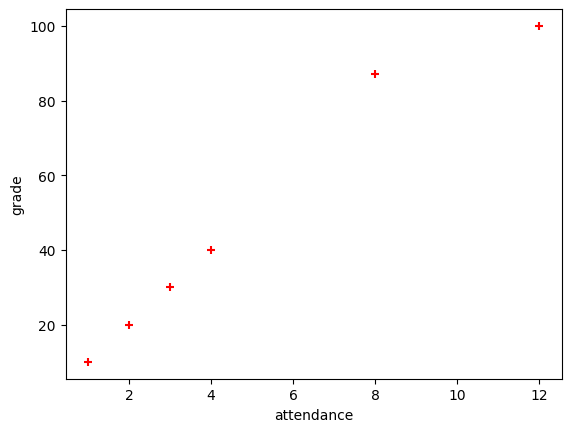

In [31]:
#View attendance and grade data using a scatterplot
%matplotlib inline
plt.xlabel('attendance')
plt.ylabel('grade')
plt.scatter(attendanceDataset.Attendance,attendanceDataset.Grades,color='red',marker='+')

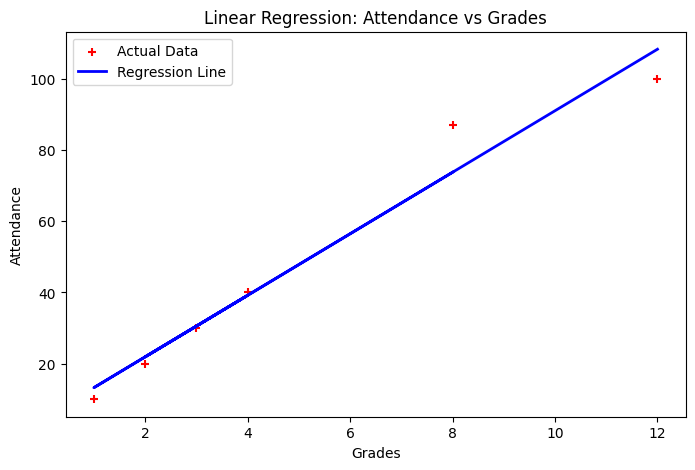

In [32]:
y_pred = model.predict(independant_variable.values)
# Create the visualization
plt.figure(figsize=(8, 5))

# Plot the actual data points (Scatter Plot)
plt.scatter(independant_variable, dependant_variable, color='red', label='Actual Data', marker='+')

# Plot the model's predictions (The Regression Line)
plt.plot(independant_variable, y_pred, color='blue', linewidth=2, label='Regression Line')

# Add formatting and labels
plt.title('Linear Regression: Attendance vs Grades')
plt.xlabel('Grades')
plt.ylabel('Attendance')
plt.legend()
plt.show()